<a href="https://colab.research.google.com/github/Raquelsantosb/analise-dados-python/blob/main/CNNeMNIST_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

# Carrega o MNIST diretamente pelo Keras
(x_treino, y_treino), (x_teste, y_teste) = tf.keras.datasets.mnist.load_data()

# Ajusta o formato para ter 4 dimensões (como o TFDS gerava: batch, 28, 28, 1)
x_treino = x_treino[..., None]
x_teste = x_teste[..., None]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Converte os valores para float32 e escala para o intervalo [0, 1]
x_treino = x_treino.astype('float32') / 255.0
x_teste = x_teste.astype('float32') / 255.0

print("Valor mínimo dos pixels:", x_treino.min())
print("Valor máximo dos pixels:", x_treino.max())

Valor mínimo dos pixels: 0.0
Valor máximo dos pixels: 1.0


In [ ]:
import tensorflow as tf

# 1. Baixa os dados do MNIST via Keras
(x_treino, y_treino), (x_teste, y_teste) = tf.keras.datasets.mnist.load_data()

# 2. Ajusta as dimensões para ficarem idênticas ao output do tfds (60000, 28, 28, 1)
x_treino = x_treino[..., None]
x_teste = x_teste[..., None]

# 3. Normaliza os pixels para o intervalo entre 0.0 e 1.0
x_treino = x_treino.astype('float32') / 255.0
x_teste = x_teste.astype('float32') / 255.0

print("Dados de treino:", x_treino.shape, y_treino.shape)
print("Dados de teste:", x_teste.shape, y_teste.shape)

Dados de treino: (60000, 28, 28, 1) (60000,)
Dados de teste: (10000, 28, 28, 1) (10000,)


O dígito na imagem: 3


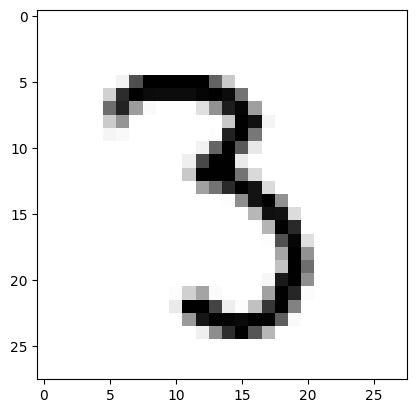

In [ ]:
# CNN 2: Visualização dos dados

import matplotlib.pyplot as plt
img_index = 8888 #You may pick a number up to 60.000
print("O dígito na imagem:", y_treino[img_index])
plt.imshow(x_treino[img_index].reshape(28,28),cmap='Greys')

In [ ]:
x_treino.shape

(60000, 28, 28, 1)

In [ ]:
# CNN 3: Remodelar e normalizar as Imagens

x_treino = x_treino.astype('float32')
x_teste = x_teste.astype('float32')
x_treino /= 255
x_teste /= 255
print('Forma de x_treino:', x_treino.shape)
print('Quantidade de imagens em x_treino', x_treino.shape[0])
print('Quantidade de imagens em x_teste', x_teste.shape[0])

Forma de x_treino: (60000, 28, 28, 1)
Quantidade de imagens em x_treino 60000
Quantidade de imagens em x_teste 10000


In [ ]:
# CNN 4: Construir a rede neural de convolução (CNN)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10, activation=tf.nn.softmax))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# CNN 5: Compilar e ajustar (fitting) o modelo

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x=x_treino, y=y_treino, epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.8209 - loss: 0.5948
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9345 - loss: 0.2187
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9527 - loss: 0.1597
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9606 - loss: 0.1303
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9659 - loss: 0.1134
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9695 - loss: 0.1009
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9728 - loss: 0.0903
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9745 - loss: 0.0828
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9758 - loss: 0.0766
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9773 - loss: 0.0712


In [ ]:
# CNN 6 AVALIAR O MODELO

model.evaluate(x_teste, y_teste)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9808 - loss: 0.0666


[0.06655167043209076, 0.9807999730110168]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Nosso modelo CNN preve que o digito na imagem é: 9


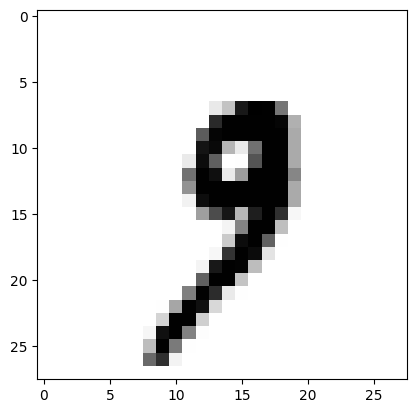

In [ ]:
# CNN 7 PREDIÇÃO DE DADOS
img_pred_index = 1000
plt.imshow(x_teste[img_pred_index].reshape(28,28), cmap='Greys')
pred = model.predict(x_teste[img_pred_index].reshape(1,28,28,1))
print("Nosso modelo CNN preve que o digito na imagem é:", pred.argmax())

In [ ]:
# CNN 8 SALVAR MODELO

import tensorflow as tf

!mkdir -p modelo_salvo
model.save('modelo_salvo/classificador_digitos.keras')

In [ ]:
# RNN 1 e 2: Importação e Carregamento Nativo do IMDB (Sem erros de TFDS)
import tensorflow as tf

# Define o tamanho do vocabulário (mesmo padrão de 8000 palavras do subwords8k)
vocab_size = 8000

# Carrega os dados de treino e teste do IMDB diretamente do Keras
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

print("Dados de treino carregados:", len(train_data))
print("Dados de teste carregados:", len(test_data))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dados de treino carregados: 25000
Dados de teste carregados: 25000


In [ ]:
# RNN 3: Compreendendo o conceito e o vocabulário (Versão Keras)

# Baixa o índice de palavras do IMDB
word_index = tf.keras.datasets.imdb.get_word_index()

# O tamanho do vocabulário que limitamos no carregamento
vocab_size = 8000

print(f'Tamanho do vocabulário: {vocab_size}')
print("Exemplo de índice da palavra 'movie':", word_index.get('movie'))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tamanho do vocabulário: 8000
Exemplo de índice da palavra 'movie': 17


In [ ]:

# RNN 4: Preparar o Dataset (Divisão, Padding e Lotes com Keras)
import tensorflow as tf

# 1. Definir o tamanho máximo para padronizar o comprimento das frases
max_length = 256

# 2. Aplicar o padding (preenchimento/corte) para todas as frases ficarem do mesmo tamanho
train_data_padded = tf.keras.preprocessing.sequence.pad_sequences(
    train_data, maxlen=max_length, padding='post', truncating='post'
)
test_data_padded = tf.keras.preprocessing.sequence.pad_sequences(
    test_data, maxlen=max_length, padding='post', truncating='post'
)

# 3. Criar os lotes (BATCH_SIZE) e embaralhar (shuffle)
BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset_treino = tf.data.Dataset.from_tensor_slices((train_data_padded, train_labels))
dataset_treino = dataset_treino.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

dataset_teste = tf.data.Dataset.from_tensor_slices((test_data_padded, test_labels))
dataset_teste = dataset_teste.batch(BATCH_SIZE)

print("Dataset de treino e teste preparados em lotes!")

Dataset de treino e teste preparados em lotes!


In [ ]:
# RNN 5: Construindo a rede neural recorrente (RNN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,
									Embedding,
									Bidirectional,
									Dropout,
									LSTM)
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

In [ ]:
# RNN 6: Criação do modelo e preenchimento das camadas

model = Sequential([
    Embedding(vocab_size, 64),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1)
])

# Força a construção do modelo definindo a dimensão da entrada (batch_size, tamanho_seq)
model.build(input_shape=(None, 256))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 256, 64)        │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,489 (2.38 MB)

 Trainable params: 623,489 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

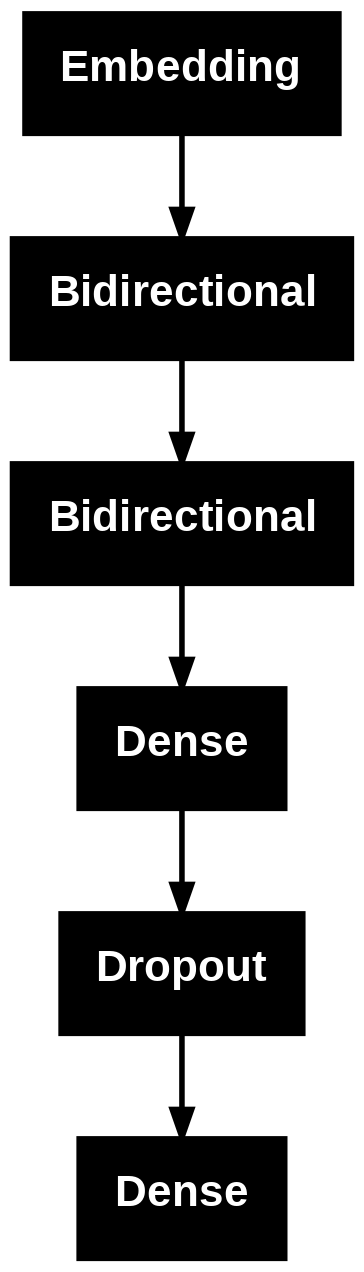

In [ ]:
tf.keras.utils.plot_model(model)

In [ ]:
# RNN 7: Compilar e ajustar o modelo
model.compile(
    loss=BinaryCrossentropy(from_logits=True),
    optimizer=Adam(1e-4),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    dataset_treino,
    epochs=3,
    validation_data=dataset_teste,
    validation_steps=30
)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 335s 832ms/step - accuracy: 0.5954 - loss: 0.6149 - val_accuracy: 0.8286 - val_loss: 0.3806
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 323s 826ms/step - accuracy: 0.8650 - loss: 0.3272 - val_accuracy: 0.8620 - val_loss: 0.3127
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 261s 668ms/step - accuracy: 0.9031 - loss: 0.2515 - val_accuracy: 0.8375 - val_loss: 0.3290


In [ ]:
# RNN 8: Avaliação do modelo
test_loss, test_acc = model.evaluate(dataset_teste)
print('Teste de perda: {}'.format(test_loss))
print('Teste de acuracia: {}'.format(test_acc))

391/391 ━━━━━━━━━━━━━━━━━━━━ 69s 175ms/step - accuracy: 0.8361 - loss: 0.3440
Teste de perda: 0.3439960479736328
Teste de acuracia: 0.8361200094223022


In [ ]:
# RNN 9: Predições
# Define a função para aplicar padding a um comentário codificado
def padding_comentario(comentario_codificado, tamanho_padding=256):
    # tf.keras.preprocessing.sequence.pad_sequences já está disponível via tf importado em outras células
    return tf.keras.preprocessing.sequence.pad_sequences([comentario_codificado], maxlen=tamanho_padding, padding='post', truncating='post')

In [ ]:
# Função para codificar o texto usando o dicionário do Keras IMDB
word_index = tf.keras.datasets.imdb.get_word_index()

def comentario_encoder(comentario):
    # Converte o texto em minúsculas e divide em palavras
    palavras = comentario.lower().split()

    # Converte cada palavra no seu ID do dicionário do IMDB (com offset de +3 padrão do Keras)
    comentario_codificado = []
    for palavra in palavras:
        id_palavra = word_index.get(palavra, -3) + 3
        # Mantém apenas palavras dentro do nosso vocabulário de 8000
        if id_palavra < 8000:
            comentario_codificado.append(id_palavra)
        else:
            comentario_codificado.append(2)  # ID 2 = Palavra desconhecida (OOV)

    # Aplica o padding usando a função que você definiu no passo anterior
    return padding_comentario(comentario_codificado, 256)

In [ ]:
comentario_matrix = 'The movie is very good. It made me wonder how advances in machine learning will influence the lives of humanity. I want to watch other films of the same type.'

In [ ]:
r = model.predict(comentario_encoder(comentario_matrix))
print(r)
resultado = lambda x: 'Avaliacao positiva' if x > 0.5 else 'Avaliacao negativa'
print (resultado(r[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
[[0.14010759]]
Avaliacao negativa
